# Feature Selection using MRMR

In [1]:
import core.constants as c
from core.utils import save_df_as_table_image, extract_subject_id
import os

import warnings

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from feature_engine.selection import SmartCorrelatedSelection
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import StratifiedGroupKFold

from feature_engine.selection import MRMR

import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
data = pd.read_csv(c.RICKD_FEATURE_SELECTION_PART_2_DATA_FILE, index_col=0)
display(data.head())

data.info(verbose=True)

,age,height,weight,gender,is_injured,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,...,dom_leg_stride_length,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,47.0,172.0,61.9,female,True,24.591474,1.552075,-6.336418,1.187877,-1.522192,...,1.891817,0.000000,78.947368,0.000000,61,-3,0.435,0.0150,96.433793,3.847659
100002_20110601T140505,37.0,173.4,70.6,male,True,24.830009,-1.873425,-4.949355,3.761674,-10.091984,...,2.001175,0.000000,81.632653,0.000000,52,23,0.445,0.0250,86.521432,-8.424086
100003_20110601T095930,51.0,186.0,86.5,male,True,25.603645,1.020660,-9.918405,2.724571,-9.056648,...,2.241927,0.000000,78.947368,0.000000,46,-14,0.445,-0.0025,76.611379,-6.069608
100004_20110203T120721,35.0,175.6,59.0,male,True,24.519444,-1.488008,-9.005590,-1.513753,-3.335102,...,1.962250,0.000000,82.191781,0.000000,44,-8,0.440,-0.0200,92.593339,9.320156
100004_20140929T102035,39.0,175.0,61.0,male,False,24.876986,-1.453904,-12.937424,-4.962587,-11.353953,...,2.108590,-0.014643,83.333333,0.574713,43,-4,0.420,-0.0100,87.481400,12.389611


<class 'pandas.core.frame.DataFrame'>
Index: 1441 entries, 100001_20110531T161051 to 201225_20140515T133244
Data columns (total 84 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    1441 non-null   float64
 1   height                                 1441 non-null   float64
 2   weight                                 1441 non-null   float64
 3   gender                                 1441 non-null   object 
 4   is_injured                             1441 non-null   bool   
 5   dom_leg_ankle_df_peak_angle            1441 non-null   float64
 6   dom_leg_diff_ankle_df_peak_angle       1441 non-null   float64
 7   dom_leg_ankle_eve_excursion            1441 non-null   float64
 8   dom_leg_diff_ankle_eve_excursion       1441 non-null   float64
 9   dom_leg_ankle_eve_peak_angle           1441 non-null   float64
 10  dom_leg_diff_ankle_eve_peak_angle     

In [3]:
y_label = "is_injured"

X = data.drop(columns=[y_label])
y = data[y_label]

subject_ids = extract_subject_id(X.index.to_series())

# To achieve an 80-20 split, we use n_splits=5 and take one fold as test (20%), rest as train (80%)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
splits = list(sgkf.split(X, y, groups=subject_ids))
train_idx, test_idx = splits[0]  # Use the first split

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

a = extract_subject_id(X_train.index.to_series())
b = extract_subject_id(X_test.index.to_series())

if np.intersect1d(a, b).size > 0:
    raise ValueError("Error: Some subjects are in both train and test sets")

print(f"Train vs Test split: {X_train.shape[0] / X.shape[0] * 100:.2f}% / {X_test.shape[0] / X.shape[0] * 100:.2f}%")
print(f"Train Shape: {X_train.shape} / Test Shape: {X_test.shape}")
print(f"Injured class distribution Train: {y_train.value_counts().iloc[0] / y_train.shape[0] * 100:.2f}%")
print(f"Injured class distribution Test: {y_test.value_counts().iloc[0] / y_test.shape[0] * 100:.2f}%")


Train vs Test split: 80.08% / 19.92%
Train Shape: (1154, 83) / Test Shape: (287, 83)
Injured class distribution Train: 72.62%
Injured class distribution Test: 72.47%


In [4]:
# Save
X_train.to_csv(c.RICKD_MODEL_1_X_TRAIN_FILE)
y_train.to_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE)
X_test.to_csv(c.RICKD_MODEL_1_X_TEST_FILE)
y_test.to_csv(c.RICKD_MODEL_1_Y_TEST_FILE)

In [5]:
# Read
X_train = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_FILE, index_col=0)
y_train = pd.read_csv(c.RICKD_MODEL_1_Y_TRAIN_FILE, index_col=0)

X_test = pd.read_csv(c.RICKD_MODEL_1_X_TEST_FILE, index_col=0)
y_test = pd.read_csv(c.RICKD_MODEL_1_Y_TEST_FILE, index_col=0)

In [6]:
x_cols = X_train.columns

cat_cols = [
    "gender",
]
num_cols = [c for c in X_train.columns if c not in cat_cols]

# Preprocessing
preprocessor = ColumnTransformer(
    verbose_feature_names_out=False,
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)

X_train_prep = preprocessor.fit_transform(X_train, y_train)
X_train_prep_df = pd.DataFrame(X_train_prep, columns=preprocessor.get_feature_names_out(), index=X_train.index)
display(X_train_prep_df.head())


,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.727682,-0.058148,-0.623476,1.118091,0.633105,1.099834,0.479364,1.447539,0.504055,1.352344,...,0.033290,-0.825146,-0.024152,0.518204,-0.295909,0.227493,1.094980,0.557382,0.334735,0.0
100002_20110601T140505,-0.150620,0.088511,0.000005,1.186679,-0.769343,1.435292,1.369072,-0.891457,-0.128827,0.772460,...,0.033290,-0.284462,-0.024152,-0.383164,2.374306,0.494990,1.801695,-0.052167,-1.015686,1.0
100004_20110203T120721,-0.326281,0.318975,-0.831303,1.097380,-0.611548,0.454303,-0.454533,0.952733,0.213660,-0.265570,...,0.033290,-0.171882,-0.024152,-1.184380,-0.809412,0.361241,-1.378523,0.321218,0.936946,1.0
100004_20140929T102035,0.025040,0.256121,-0.687974,1.200187,-0.597585,-0.496600,-1.646722,-1.235893,-0.149788,-1.023207,...,-2.375712,0.057971,2.242683,-1.284532,-0.398610,-0.173754,-0.671808,0.006865,1.274719,1.0
100005_20110208T120837,-0.501941,-1.336177,-0.974632,0.700173,-0.055702,1.219604,0.074521,-0.082042,-0.504754,0.652176,...,0.033290,1.723083,-0.024152,-1.484836,-0.398610,-1.511240,0.388265,-1.061532,-0.356889,1.0


In [7]:
X_test_prep = preprocessor.fit_transform(X_test, y_test)
X_test_prep_df = pd.DataFrame(X_test_prep, columns=preprocessor.get_feature_names_out(), index=X_test.index)
display(X_test_prep_df.head())

,age,height,weight,dom_leg_ankle_df_peak_angle,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_excursion,dom_leg_diff_ankle_eve_excursion,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,...,dom_leg_diff_stride_length,dom_leg_stride_rate,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_diff_supination_timing,dom_leg_swing_time,dom_leg_diff_swing_time,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation,gender_male
id,,,,,,,,,,,,,,,,,,,,,
100003_20110601T095930,1.161325,1.553769,1.270721,1.503571,0.461656,0.194918,0.974177,-0.618237,0.001106,-0.144836,...,0.039518,-0.742179,-0.036995,-0.924678,-1.521705,0.434439,-0.151744,-0.650628,-0.812252,1.0
100009_20110302T140353,-0.485672,-1.437124,-1.853143,-0.025796,-0.824566,0.519048,-1.078329,1.009302,1.181976,0.452166,...,0.039518,-0.033226,-0.036995,0.667805,2.562815,-0.030438,-0.151744,-0.782941,-0.541116,0.0
100016_20110329T161600,1.681429,-0.524844,-0.230357,0.003631,-1.616307,1.528629,0.155237,0.440786,1.299376,1.901808,...,1.068238,-0.513665,-1.084160,0.012077,0.049264,0.376329,-0.151744,-0.091992,-0.124176,1.0
100022_20110418T115212,-1.439197,-0.490200,-0.993066,1.176049,-1.723848,-2.179607,-2.532933,-0.532760,-0.045647,-1.578676,...,-1.201613,0.016479,1.083894,0.574129,1.829696,0.899316,0.024099,0.590588,-0.110052,1.0
100026_20110406T140656,1.161325,-1.448672,-0.619825,-0.031067,0.984987,1.871094,1.740552,1.339184,-0.420527,1.384543,...,0.039518,0.920918,-0.036995,-0.737327,-0.788586,-0.146658,1.430849,-0.826129,-0.443156,0.0


In [8]:
# Save
X_train_prep_df.to_csv(c.RICKD_MODEL_1_X_TRAIN_PREPROCESSED_FILE)
X_test_prep_df.to_csv(c.RICKD_MODEL_1_X_TEST_PREPROCESSED_FILE)

In [9]:
# Read
X_train_prep_df = pd.read_csv(c.RICKD_MODEL_1_X_TRAIN_PREPROCESSED_FILE, index_col=0)
X_test_prep_df = pd.read_csv(c.RICKD_MODEL_1_X_TEST_PREPROCESSED_FILE, index_col=0)

In [10]:
# We want stable importance ranking:
# We want enough complexity to capture non-linear relationships.
# We want enough randomness so feature importances aren’t biased toward high-cardinality variables.
# We want parameters that avoid overfitting
param_grid = {
    "n_estimators": [500],  # More provides more stability.
    "max_depth": [5, 10], 
    "min_samples_leaf": [2, 5, 8],
    "max_features": ["sqrt", "log2"],  # Give smaller features a chance to be selected
    "min_samples_split": [4, 10, 16],  # Proportional to min_samples_leaf
    "bootstrap": [True]  # So each tree sees a slightly different dataset
}

sel = MRMR( 
        method="RFCQ",
        scoring="roc_auc",
        param_grid = param_grid,
        cv=3,
        regression=False,
        max_features=40,
        random_state=RANDOM_STATE,
    )
sel.fit(X_train_prep_df, y_train)

/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Documents/Personal/TFM/rickd-analysis/.venv/lib/python3.11/site-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/Users/adrianzapaterreig/Docume

MRMR(max_features=40, method='RFCQ',
     param_grid={'bootstrap': [True], 'max_depth': [5, 10],
                 'max_features': ['sqrt', 'log2'],
                 'min_samples_leaf': [2, 5, 8],
                 'min_samples_split': [4, 10, 16], 'n_estimators': [500]},
     random_state=42)

In [11]:
pd.Series(sel.relevance_, index=sel.variables_).to_csv(os.path.join(c.RICKD_PROCESSED_DATA_FOLDER, "mrmr_relevance_RFCQ_40.csv"))

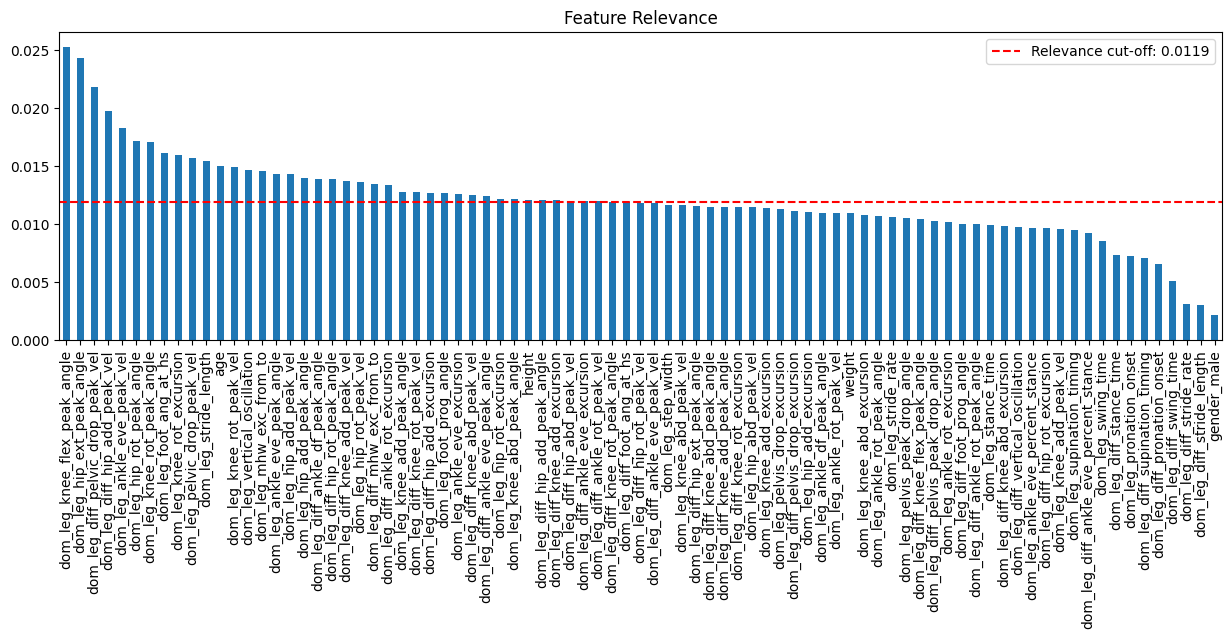

In [12]:
relevance_cutoff = sorted(sel.relevance_, reverse=True)[39]
ax = pd.Series(sel.relevance_, index=sel.variables_).sort_values(
    ascending=False).plot.bar(figsize=(15, 4))
plt.axhline(relevance_cutoff, color='red', linestyle='--', label=f'Relevance cut-off: {relevance_cutoff:.4f}')
plt.title("Feature Relevance")
plt.legend()
plt.show()

In [13]:
sorted_vars = sorted(zip(sel.variables_, sel.relevance_), key=lambda x: x[1], reverse=True)
for i, (var, rel) in enumerate(sorted_vars):
    print(f"{i}: {var}: {rel}")

0: dom_leg_knee_flex_peak_angle: 0.025267141243328843
1: dom_leg_hip_ext_peak_angle: 0.024289711757585247
2: dom_leg_diff_pelvic_drop_peak_vel: 0.021762879446166904
3: dom_leg_diff_hip_add_peak_vel: 0.019722427915747315
4: dom_leg_ankle_eve_peak_vel: 0.018282729018142332
5: dom_leg_hip_rot_peak_angle: 0.017135611886641186
6: dom_leg_knee_rot_peak_angle: 0.01701426479852255
7: dom_leg_foot_ang_at_hs: 0.016075673240752823
8: dom_leg_knee_rot_excursion: 0.015945604146880225
9: dom_leg_pelvic_drop_peak_vel: 0.01568552147423076
10: dom_leg_stride_length: 0.015396994555525022
11: age: 0.014985408883441674
12: dom_leg_knee_rot_peak_vel: 0.01486146765065357
13: dom_leg_vertical_oscillation: 0.014619846154191358
14: dom_leg_mhw_exc_from_to: 0.01457996837539649
15: dom_leg_ankle_eve_peak_angle: 0.014267597281204861
16: dom_leg_hip_add_peak_vel: 0.014261664681910376
17: dom_leg_hip_add_peak_angle: 0.01392362684227694
18: dom_leg_diff_ankle_df_peak_angle: 0.013825550881187133
19: dom_leg_diff_hip_

In [19]:
print("="*30)
print("X Train with 40 selected features")
print("="*30)
X_train_sel = sel.transform(X_train_prep_df)
display(X_train_sel.head())
print(X_train_sel.info(verbose=True))

print("\n="*30)
print("X Test with 40 selected features")
print("="*30)
X_test_sel = sel.transform(X_test_prep_df)
display(X_test_sel.head())
print(X_test_sel.info(verbose=True))

X_train_sel.to_csv(c.RICKD_MODEL_1_X_TRAIN_FILE_40_FEATURES)
X_test_sel.to_csv(c.RICKD_MODEL_1_X_TEST_FILE_40_FEATURES)

X Train with 40 selected features


,age,height,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_diff_ankle_rot_excursion,dom_leg_diff_ankle_rot_peak_angle,...,dom_leg_pelvic_drop_peak_vel,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_diff_pelvis_drop_excursion,dom_leg_diff_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100001_20110531T161051,0.727682,-0.058148,0.633105,1.447539,0.504055,1.352344,0.367857,-0.230089,0.814120,-1.231183,...,0.077306,-0.964662,1.499872,-1.080393,1.983425,-0.244786,-0.024152,0.518204,0.557382,0.334735
100002_20110601T140505,-0.150620,0.088511,-0.769343,-0.891457,-0.128827,0.772460,1.501485,0.540020,0.693086,0.001899,...,0.770352,0.280063,1.441758,-1.778995,-0.857244,0.103879,-0.024152,-0.383164,-0.052167,-1.015686
100004_20110203T120721,-0.326281,0.318975,-0.611548,0.952733,0.213660,-0.265570,-0.682724,-0.340104,0.177909,1.795760,...,0.611224,-0.465172,1.362814,1.364717,-1.532790,-0.020226,-0.024152,-1.184380,0.321218,0.936946
100004_20140929T102035,0.025040,0.256121,-0.597585,-1.235893,-0.149788,-1.023207,-1.082561,0.209973,-0.218022,0.917178,...,1.481642,1.031569,1.266941,0.666114,-0.979693,0.446352,2.242683,-1.284532,0.006865,1.274719
100005_20110208T120837,-0.501941,-1.336177,-0.055702,-0.082042,-0.504754,0.652176,-0.658743,-0.670150,-0.799613,-0.040992,...,0.820841,-0.513202,0.073574,-0.032488,-0.415119,-0.653740,-0.024152,-1.484836,-1.061532,-0.356889


<class 'pandas.core.frame.DataFrame'>
Index: 1154 entries, 100001_20110531T161051 to 201225_20140515T133244
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    1154 non-null   float64
 1   height                                 1154 non-null   float64
 2   dom_leg_diff_ankle_df_peak_angle       1154 non-null   float64
 3   dom_leg_ankle_eve_peak_angle           1154 non-null   float64
 4   dom_leg_diff_ankle_eve_peak_angle      1154 non-null   float64
 5   dom_leg_ankle_eve_peak_vel             1154 non-null   float64
 6   dom_leg_diff_ankle_eve_peak_vel        1154 non-null   float64
 7   dom_leg_diff_ankle_eve_percent_stance  1154 non-null   float64
 8   dom_leg_diff_ankle_rot_excursion       1154 non-null   float64
 9   dom_leg_diff_ankle_rot_peak_angle      1154 non-null   float64
 10  dom_leg_foot_ang_at_hs                

,age,height,dom_leg_diff_ankle_df_peak_angle,dom_leg_ankle_eve_peak_angle,dom_leg_diff_ankle_eve_peak_angle,dom_leg_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_peak_vel,dom_leg_diff_ankle_eve_percent_stance,dom_leg_diff_ankle_rot_excursion,dom_leg_diff_ankle_rot_peak_angle,...,dom_leg_pelvic_drop_peak_vel,dom_leg_diff_pelvic_drop_peak_vel,dom_leg_diff_pelvis_drop_excursion,dom_leg_diff_stance_time,dom_leg_step_width,dom_leg_stride_length,dom_leg_diff_stride_rate,dom_leg_supination_timing,dom_leg_vertical_oscillation,dom_leg_diff_vertical_oscillation
id,,,,,,,,,,,,,,,,,,,,,
100003_20110601T095930,1.161325,1.553769,0.461656,-0.618237,0.001106,-0.144836,0.746413,-1.845151,-1.453711,-0.116536,...,-0.408926,-0.465858,-0.387080,-0.018249,1.015518,0.949487,-0.036995,-0.924678,-0.650628,-0.812252
100009_20110302T140353,-0.485672,-1.437124,-0.824566,1.009302,1.181976,0.452166,-0.854073,0.381443,-0.306259,0.375048,...,-0.290479,0.350289,1.805270,-0.018249,0.425533,-0.519891,-0.036995,0.667805,-0.782941,-0.541116
100016_20110329T161600,1.681429,-0.524844,-1.616307,0.440786,1.299376,1.901808,1.358861,1.494740,0.745181,-1.358497,...,-0.137241,0.813809,1.894056,0.338858,2.008321,-0.344536,-1.084160,0.012077,-0.091992,-0.124176
100022_20110418T115212,-1.439197,-0.490200,-1.723848,-0.532760,-0.045647,-1.578676,-1.487756,0.699528,-0.243709,-0.426754,...,0.922621,0.796283,-0.193610,-0.375357,-0.898443,0.628830,1.083894,0.574129,0.590588,-0.110052
100026_20110406T140656,1.161325,-1.448672,0.984987,1.339184,-0.420527,1.384543,0.693315,-1.368024,-0.485009,-3.604030,...,-0.435811,-0.059818,1.656587,-1.089571,1.710928,-1.352721,-0.036995,-0.737327,-0.826129,-0.443156


<class 'pandas.core.frame.DataFrame'>
Index: 287 entries, 100003_20110601T095930 to 201101_20150413T143152
Data columns (total 40 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   age                                    287 non-null    float64
 1   height                                 287 non-null    float64
 2   dom_leg_diff_ankle_df_peak_angle       287 non-null    float64
 3   dom_leg_ankle_eve_peak_angle           287 non-null    float64
 4   dom_leg_diff_ankle_eve_peak_angle      287 non-null    float64
 5   dom_leg_ankle_eve_peak_vel             287 non-null    float64
 6   dom_leg_diff_ankle_eve_peak_vel        287 non-null    float64
 7   dom_leg_diff_ankle_eve_percent_stance  287 non-null    float64
 8   dom_leg_diff_ankle_rot_excursion       287 non-null    float64
 9   dom_leg_diff_ankle_rot_peak_angle      287 non-null    float64
 10  dom_leg_foot_ang_at_hs                 